
# UniMol

Подход к предсказанию со-кристаллизации с использованием энкодера Uni-Mol, предназначенного для работы с трёхмерными молекулярными структурами. Каждая система представляется в виде 3D-геометрий трёх молекул. Для каждой молекулы предобученный энкодер Uni-Mol формирует эмбеддинг, после чего эмбеддинги трёх компонентов объединяются в общее представление системы, учитывающее как усреднённые свойства молекул, так и различия между ними.

Обучение проводится в две стадии. На первом этапе оптимизируется только классификатор поверх предобученного энкодера, а на втором размораживается последний слой энкодера и выполняется его совместное дообучение с классификатором, что позволяет адаптировать модель к задаче со-кристаллизации. В ноутбуке показаны подготовка данных, построение входного представления, обучение модели, подбор порога классификации и оценка качества на валидационной, тестовой и независимой экспериментальной выборках. Экспериментальный датасет имеет сильный сдвиг домена и нужен для проверки обобщающей способности модели.

Функции вынесены в [src/models/unimol_classifier.py](../src/models/unimol_classifier.py)


In [ ]:
from pathlib import Path
import sys

root = Path('..').resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import clear_output, display

from src.models.unimol_classifier import (
    TripleUniMolDataset,
    TripleUniMolClassifier,
    build_optimizer,
    build_unimol_dictionary,
    collect_probs_targets,
    compute_pos_weight,
    evaluate_loader,
    find_best_threshold,
    initialize_model,
    make_loader,
    run_stage,
    save_experiment_outputs,
    seed_everything,
    split_dataframe,
    summarize_two_stage_training,
)


In [ ]:
seed = 42
seed_everything(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = root / 'models' / 'unimol'
save_dir.mkdir(parents=True, exist_ok=True)

final_checkpoint_path = save_dir / 'checkpoint.pt'

print('device:', device)
print('save_dir:', save_dir)


### Загрузка данных

Основной датасет разделяется на тренировочный, валидационный и тестовый

sulf - дополнительный тестовый датасет, собраный на основе лабораторных экспериментом, с сильным domain shift


In [13]:

df = pd.read_pickle(root / 'data' / 'final' / 'triple_real_xtb.pkl')
sulf_df = pd.read_pickle(root / 'data' / 'final' / 'sulf_rebuilt_xtb.pkl')

train_inner_df, val_df, test_df = split_dataframe(
    df,
    target_col='cryst',
    test_size=0.2,
    val_size=0.2,
    random_state=seed,
)

In [14]:
df.head(2)

,source_file,formula_1,xyz_1_3d,formula_2,xyz_2_3d,formula_3,xyz_3_3d,xtb_1_3d,xtb_2_3d,xtb_3_3d,xtb_concat_3d,cryst
0,GATCAH,GdC46N6(ClO4)2,126\nGd2 C92 N12 Cl4 O16\nC -1.911545 2.376586...,C3NO,5\nC3 N1 O1\nC -0.400809 -0.551343 -0.789440\n...,ClO4,5\nCl1 O4\nO -1.098584 0.802731 0.395786\nO -0...,"[1.0, 1.0, -314.9685994404997, 126.0, -2.49975...","[1.0, 1.0, -13.22904652994901, 5.0, -2.6458093...","[1.0, 1.0, -20.39468970230421, 5.0, -4.0789379...","[1.0, 1.0, -314.9686, 126.0, -2.4997509, 7.076...",1
1,ZESSUL,EuC24(N2O3)2,70\nEu2 C48 N8 O12\nO 0.797972 1.673834 -0.006...,C5N,12\nC10 N2\nC -2.795876 -0.601193 0.610952\nC ...,ClO4,5\nCl1 O4\nO 1.375560 -0.122040 0.309645\nO -0...,"[1.0, 1.0, -175.22370355489122, 70.0, -2.50319...","[1.0, 1.0, -26.738125111357956, 12.0, -2.22817...","[1.0, 1.0, -20.394692431724913, 5.0, -4.078938...","[1.0, 1.0, -175.22371, 70.0, -2.5031958, 4.955...",1


In [15]:
sulf_df.head(2)

,A,B,G,cryst,xyz_1_rebuilt,xyz_2_rebuilt,xyz_3_rebuilt,xtb_1_rebuilt,xtb_2_rebuilt,xtb_3_rebuilt,xtb_concat_rebuilt
0,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CC1=CC(C)=C(O)C=C1,1,15\n\nN -2.736585 3.146700 -0.842205\nC -1.866...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC -0.321045 -0.211138 -3.289374\nC -0.353...,"[1.0, 1.0, -35.05280903585239, 15.0, -2.336853...","[1.0, 1.0, -29.881285250719998, 11.0, -2.71648...","[1.0, 1.0, -20.76658446705264, 9.0, -2.3073982...","[1.0, 1.0, -35.05280903585239, 15.0, -2.336853..."
1,[NH3+]C1=CC=C(OC2=CC=C([NH3+])C=C2)C=C1,CC1=CC=C(S(=O)(=O)[O-])C=C1,CCC1=C(O)C=CC=C1,1,15\n\nN -2.779333 3.134391 -0.757041\nC -1.905...,11\n\nC -1.581266 -0.695319 1.971559\nC -0.737...,9\n\nC 0.725632 1.341181 -5.871308\nC 0.614510...,"[1.0, 1.0, -35.05280699650334, 15.0, -2.336853...","[1.0, 1.0, -29.881285250722144, 11.0, -2.71648...","[1.0, 1.0, -20.836285365916474, 9.0, -2.315142...","[1.0, 1.0, -35.05280699650334, 15.0, -2.336853..."


Подготовка UniMol-входов

In [16]:

_, dictionary, pad_idx = build_unimol_dictionary(remove_hs=True)
xyz_cols = ('xyz_1_3d', 'xyz_2_3d', 'xyz_3_3d')
sulf_xyz_cols = ('xyz_1_rebuilt', 'xyz_2_rebuilt', 'xyz_3_rebuilt')
max_atoms = 256
batch_size = 16

train_dataset = TripleUniMolDataset(train_inner_df, dictionary=dictionary, xyz_cols=xyz_cols, max_atoms=max_atoms)
val_dataset = TripleUniMolDataset(val_df, dictionary=dictionary, xyz_cols=xyz_cols, max_atoms=max_atoms)
test_dataset = TripleUniMolDataset(test_df, dictionary=dictionary, xyz_cols=xyz_cols, max_atoms=max_atoms)
sulf_dataset = TripleUniMolDataset(sulf_df, dictionary=dictionary, xyz_cols=sulf_xyz_cols, max_atoms=max_atoms)

train_loader = make_loader(train_dataset, pad_idx, batch_size=batch_size, shuffle=True)
val_loader = make_loader(val_dataset, pad_idx, batch_size=batch_size, shuffle=False)
test_loader = make_loader(test_dataset, pad_idx, batch_size=batch_size, shuffle=False)
sulf_loader = make_loader(sulf_dataset, pad_idx, batch_size=batch_size, shuffle=False)

print('train dataset:', len(train_dataset))
print('validation dataset:', len(val_dataset))
print('test dataset:', len(test_dataset))
print('sulf dataset:', len(sulf_dataset))


train dataset: 122957
validation dataset: 30746
test dataset: 38443
sulf dataset: 85


### Вызов модели
Архитектура классификатора находится в `src/models/unimol_classifier.py`


In [5]:

model = TripleUniMolClassifier(dropout=0.3).to(device)
model = initialize_model(model, train_loader, device)

n_neg, n_pos, pos_weight = compute_pos_weight(train_inner_df, target_col='cryst')
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device)
)

print('repr_dim:', model.repr_dim)
print('n_neg:', n_neg)
print('n_pos:', n_pos)
print('pos_weight:', pos_weight)


2026-04-25 07:44:04 | unimol_tools/models/unimol.py | 167 | INFO | Uni-Mol Tools | Loading pretrained weights from /home/igic/miniconda3/envs/nastya_unimol/lib/python3.10/site-packages/unimol_tools/weights/mol_pre_all_h_220816.pt


repr_dim: 512
n_neg: 119655
n_pos: 3638
pos_weight: 32.89032435404068



### Стадия 1. Обучение классификатора на стандартных эмбеддингах для стабилизации весов 


In [ ]:

optimizer_stage1 = build_optimizer(
    model,
    stage='head_only',
    head_lr=1e-4,
    weight_decay=1e-4,
)

scheduler_stage1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage1,
    mode='max',
    factor=0.5,
    patience=2,
)

stage1_results = run_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    stage_name='Stage 1 | head only',
    optimizer=optimizer_stage1,
    n_epochs=5,
    patience=3,
    scheduler=scheduler_stage1,
    clear_output_fn=clear_output,
)

model.load_state_dict(stage1_results['best_model_state'])


In [ ]:
print('Best stage 1 val ROC-AUC:', round(stage1_results['best_val_roc_auc'], 3))
print('Best stage 1 epoch      :', stage1_results['best_epoch'])



### Подбор порога и проверка качества 1 стадии

In [16]:
stage1_val_probs, stage1_val_targets = collect_probs_targets(model, val_loader, device)

stage1_best_threshold, stage1_best_val_f2, stage1_best_val_precision, stage1_best_val_recall, stage1_threshold_df = find_best_threshold(
    stage1_val_targets,
    stage1_val_probs,
    beta=2.0,
)

print(f'Stage 1 best threshold on validation: {stage1_best_threshold:.4f}')
print(f'Stage 1 validation F2 at best threshold: {stage1_best_val_f2:.4f}')
print(f'Stage 1 validation recall: {stage1_best_val_recall:.4f}')
print(f'Stage 1 validation precision: {stage1_best_val_precision:.4f}')

Stage 1 best threshold on validation: 0.3150
Stage 1 validation F2 at best threshold: 0.6560
Stage 1 validation recall: 0.7308
Stage 1 validation precision: 0.4655


Stage 1 | Validation dataset
ROC-AUC  : 0.9596
Recall   : 0.7308
Precision: 0.4655
Stage 1 | Test dataset
ROC-AUC  : 0.9535
Recall   : 0.7143
Precision: 0.4693
Stage 1 | Experimental
ROC-AUC  : 0.6813
Recall   : 0.0000
Precision: 0.0000


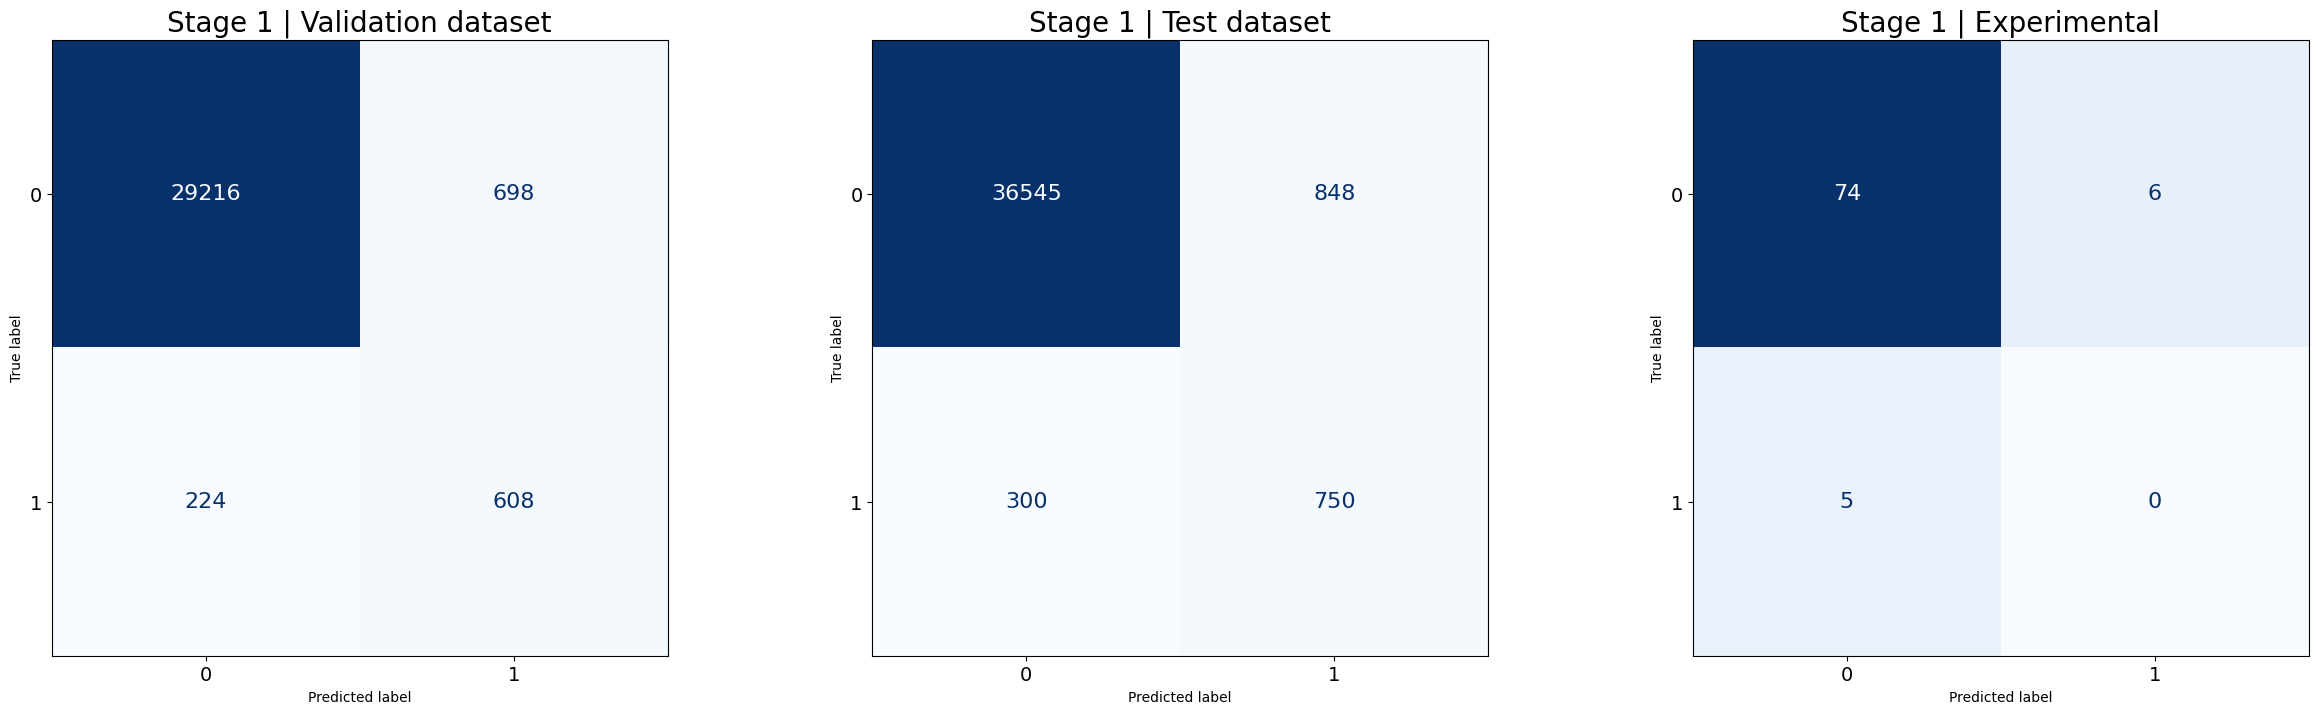

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

stage1_results_val = evaluate_loader(
    model,
    val_loader,
    device=device,
    title=f'Stage 1 | Validation dataset',
    threshold=stage1_best_threshold,
    ax=axes[0],
)

stage1_results_test = evaluate_loader(
    model,
    test_loader,
    device=device,
    title=f'Stage 1 | Test dataset',
    threshold=stage1_best_threshold,
    ax=axes[1],
)

stage1_results_sulf = evaluate_loader(
    model,
    sulf_loader,
    device=device,
    title=f'Stage 1 | Experimental',
    threshold=stage1_best_threshold,
    ax=axes[2],
)

### Стадия 2. Совместное дообучение классификатора с последним слоем энкодера UniMol

In [ ]:

optimizer_stage2 = build_optimizer(
    model,
    stage='head_last_layer',
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
)

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode='max',
    factor=0.5,
    patience=2,
)

stage2_results = run_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    device=device,
    stage_name='Stage 2 | head + last UniMol layer',
    optimizer=optimizer_stage2,
    n_epochs=15,
    patience=4,
    scheduler=scheduler_stage2,
    global_epoch_offset=len(stage1_results['history']),
    clear_output_fn=clear_output,
)

model.load_state_dict(stage2_results['best_model_state'])
model.eval()



### Сравнение двух стадий

In [ ]:
summary = summarize_two_stage_training(stage1_results, stage2_results)
history_df = summary['history_df']
best_model_state = summary['best_model_state']
best_stage_name = summary['best_stage_name']
best_epoch = summary['best_epoch']
best_val_roc_auc = summary['best_val_roc_auc']

model.load_state_dict(best_model_state)
model.eval()

print('Best stage:', best_stage_name)
print('Best global epoch:', best_epoch)
print('Best val ROC-AUC:', round(best_val_roc_auc, 3))


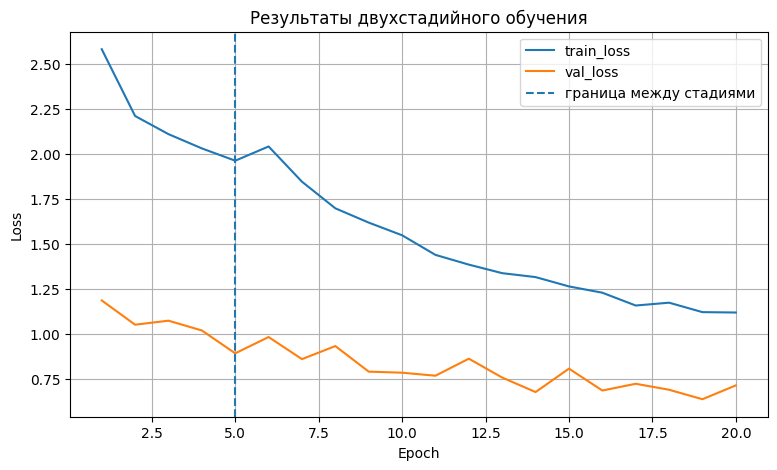

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(history_df['global_epoch'], history_df['train_loss'], label='train_loss')
plt.plot(history_df['global_epoch'], history_df['val_loss'], label='val_loss')
plt.axvline(len(stage1_results['history']), linestyle='--', label='граница между стадиями')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Результаты двухстадийного обучения')
plt.legend()
plt.grid(True)
plt.show()


### Подбор порога и проверка качества 2 стадии


In [22]:
val_probs, val_targets = collect_probs_targets(model, val_loader, device)

best_threshold, best_val_f2, best_val_precision, best_val_recall, threshold_df = find_best_threshold(
    val_targets,
    val_probs,
    beta=2.0,
)

print(f'Best threshold on validation: {best_threshold:.4f}')
print(f'Validation F2 at best threshold: {best_val_f2:.4f}')
print(f'Validation recall: {best_val_recall:.4f}')
print(f'Validation precision: {best_val_precision:.4f}')

Best threshold on validation: 0.4000
Validation F2 at best threshold: 0.8182
Validation recall: 0.8534
Validation precision: 0.7023


Валидационная выборка
ROC-AUC  : 0.9846
Recall   : 0.8534
Precision: 0.7023
Тестовая выборка
ROC-AUC  : 0.9848
Recall   : 0.8457
Precision: 0.6862
Экспериментальная выборка
ROC-AUC  : 0.5613
Recall   : 0.8000
Precision: 0.1111


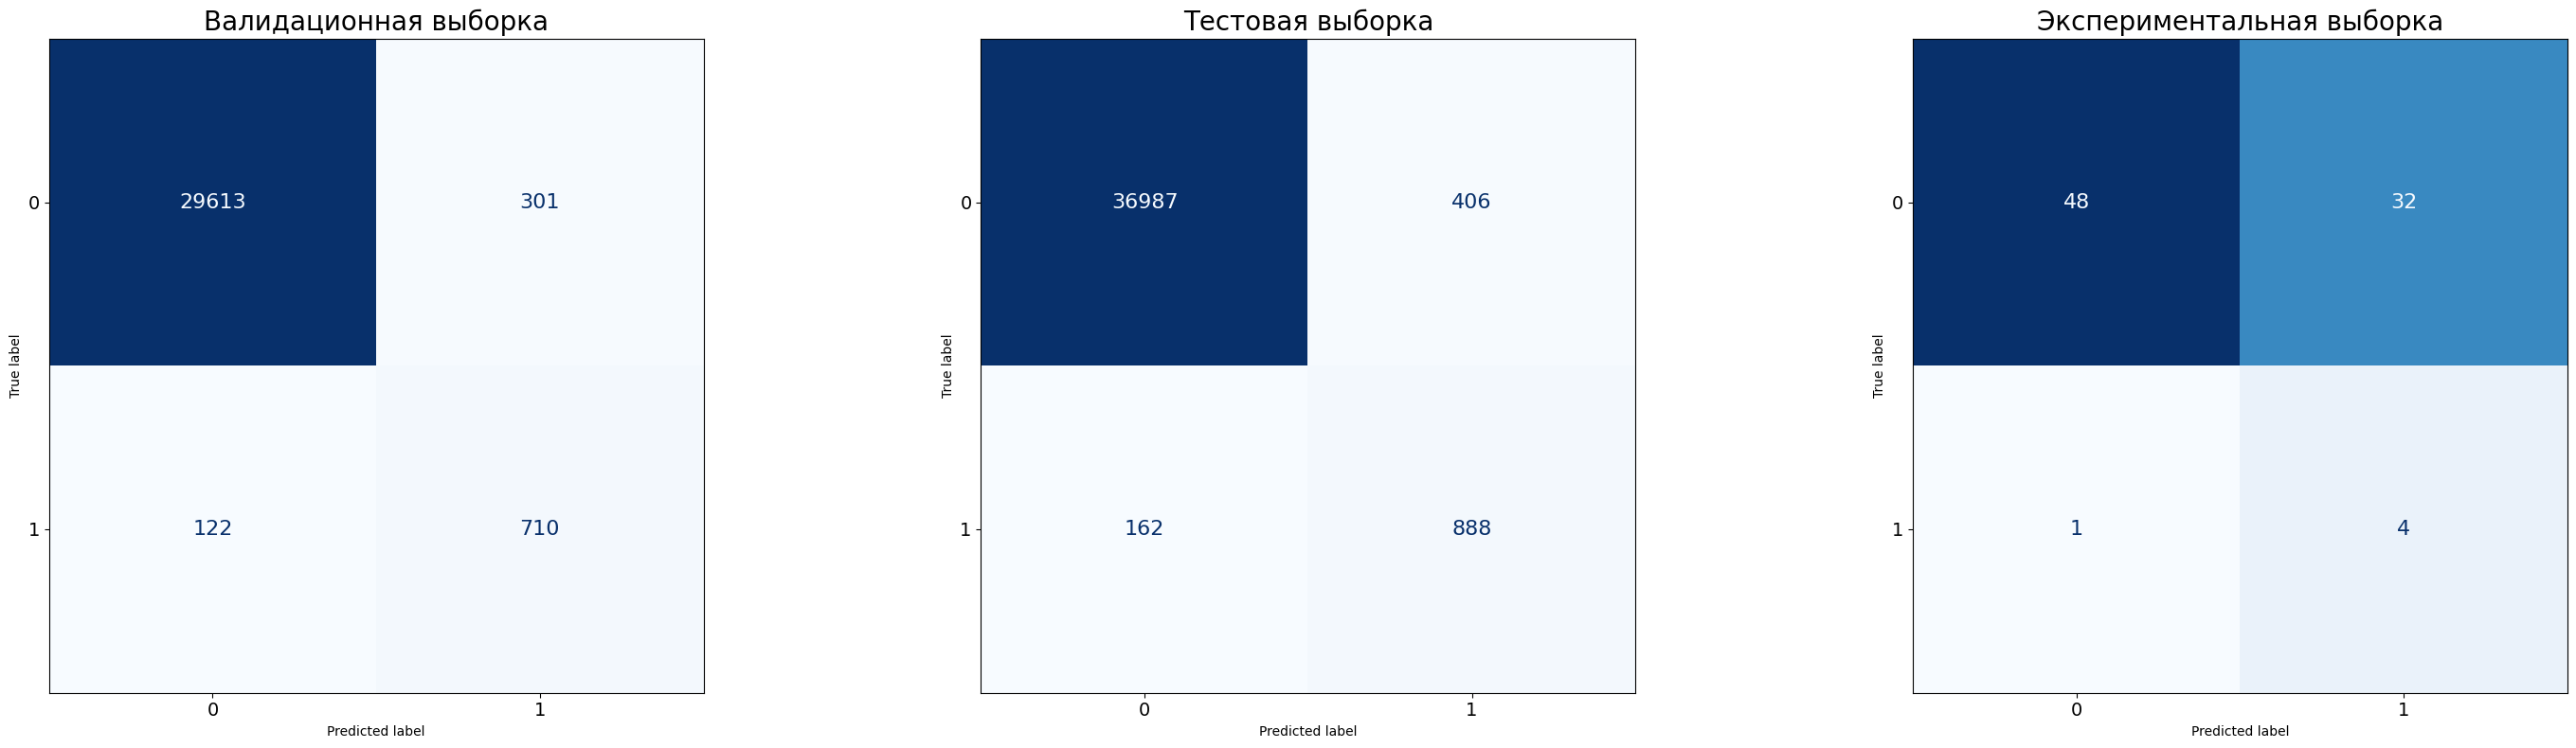

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

results_val = evaluate_loader(
    model,
    val_loader,
    device=device,
    title=f'Валидационная выборка',
    threshold=best_threshold,
    ax=axes[0],
)

results_test = evaluate_loader(
    model,
    test_loader,
    device=device,
    title=f'Тестовая выборка',
    threshold=best_threshold,
    ax=axes[1],
)

results_sulf = evaluate_loader(
    model,
    sulf_loader,
    device=device,
    title=f'Экспериментальная выборка',
    threshold=best_threshold,
    ax=axes[2],
)

plt.tight_layout()
plt.show()

Несмотря на снижение ROC‑AUC до 0.561, модель сохранила recall 0.800 и корректно распознала 4 из 5 положительных примеров. Тем самым Uni‑Mol, в отличие от бустинга, не деградировала при переносе на данные с выраженным domain shift и сохранила способность выявлять положительные случаи со‑кристаллизации

Сохранение артефактов 

In [ ]:
save_experiment_outputs(
    save_dir=save_dir,
    model=model,
    best_model_state=best_model_state,
    best_threshold=best_threshold,
)

print('Saved to:', final_checkpoint_path)
